In [54]:
import os
import datetime
from Functions.Utils import *
from Functions.Graphs import *
import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler


mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

In [55]:
dfs = [pd.DataFrame() for i in range(3)]
paths = [r'Datasets\DEVRT\NISSAN_LEAF_TRAIN',r'Datasets\DEVRT\NISSAN_LEAF_TEST', r'Datasets\DEVRT\NISSAN_LEAF_VAL']
column_names = ['Elv', 'Speed', 'AmbTemp', 'Regenwh', 'MotorTemp', 'Torque', 'RPM', 'Power']
for i,path in enumerate(paths):
    samples = os.listdir(path)
    for sample in samples[:]:
        df = pd.read_csv(os.path.join(path,sample))
        df = df.ffill().bfill()
        dfs[i] = pd.concat([dfs[i],df])
    pwr = dfs[i]['Motor Pwr(w)'].values[1:]
    dfs[i] = dfs[i].drop(columns=['timestamp_data_utc','timestamp_gps_utc', 'car_id', 'time_diff', 'point_geom', 'route_code',
        'route_description', 'driver', 'start_timestamp', 'end_timestamp','car_code', 'car_description', 'ref_consumption',
        'timestamp_weather_utc','wind_mph', 'wind_kph', 'wind_degree','wind_dir', 'Frontal_Wind', 'Veh_deg', 'totalVehicles', 'speedAvg',
        'cars_by_speed_interval_0_80', 'cars_by_speed_interval_80_100','cars_by_speed_interval_100_120', 'cars_by_speed_interval_0_50',
        'cars_by_speed_interval_50_80', 'cars_by_speed_interval_80_120','cars_by_speed_interval_120_inf', 'cars_by_length_interval_0_7',
        'cars_by_length_interval_7_inf', 'max_speed','Motor Pwr(w)', 'route_id','Aux Pwr(100w)','capacity', 'soh','soc','radius',
        'longitude', 'latitude', 'altitude', 'cumul_dist'])
    dfs[i] = dfs[i][:-1].copy()
    dfs[i]['power'] = pwr
    dfs[i] = dfs[i].reset_index(drop=True)
    dfs[i].columns = column_names
train, test, val = dfs

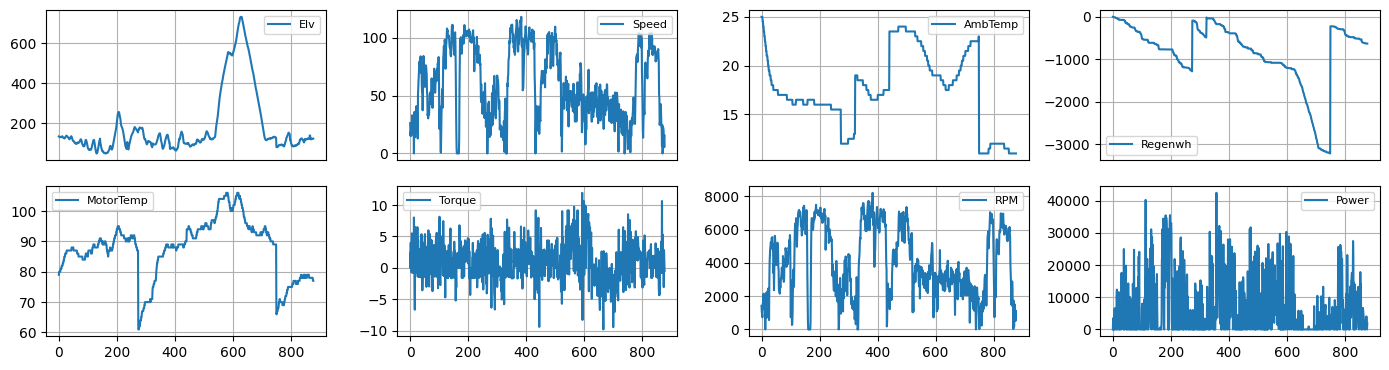

In [56]:
PlotDataframes([test],w=14,h=4)

In [57]:
scaler = MinMaxScaler()
scaler.fit(train)
train_n = scaler.fit_transform(train)
test_n = scaler.fit_transform(test)
val_n = scaler.fit_transform(val)
train_df = pd.DataFrame(train_n, columns=column_names, index=train.index)
test_df = pd.DataFrame(test_n, columns=column_names, index=test.index)
val_df = pd.DataFrame(val_n, columns=column_names, index=val.index)

column_indices = {name: i for i, name in enumerate(train.columns)}


num_features = train_df.shape[1]

In [58]:
class WindowGenerator():
  def __init__(self, input_width, label_width, shift,
               train_df=train_df, val_df=val_df, test_df=test_df,
               label_columns=None):
    # Store the raw data.
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df

    # Work out the label column indices.
    self.label_columns = label_columns
    if label_columns is not None:
      self.label_columns_indices = {name: i for i, name in
                                    enumerate(label_columns)}
    self.column_indices = {name: i for i, name in
                           enumerate(train_df.columns)}

    # Work out the window parameters.
    self.input_width = input_width
    self.label_width = label_width
    self.shift = shift

    self.total_window_size = input_width + shift

    self.input_slice = slice(0, input_width)
    self.input_indices = np.arange(self.total_window_size)[self.input_slice]

    self.label_start = self.total_window_size - self.label_width
    self.labels_slice = slice(self.label_start, None)
    self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

  def __repr__(self):
    return '\n'.join([
        f'Total window size: {self.total_window_size}',
        f'Input indices: {self.input_indices}',
        f'Label indices: {self.label_indices}',
        f'Label column name(s): {self.label_columns}'])
  
def split_window(self, features):
  inputs = features[:, self.input_slice, :]
  labels = features[:, self.labels_slice, :]
  if self.label_columns is not None:
    labels = tf.stack(
        [labels[:, :, self.column_indices[name]] for name in self.label_columns],
        axis=-1)

  # Slicing doesn't preserve static shape information, so set the shapes
  # manually. This way the `tf.data.Datasets` are easier to inspect.
  inputs.set_shape([None, self.input_width, None])
  labels.set_shape([None, self.label_width, None])

  return inputs, labels

In [59]:
w1 = WindowGenerator(input_width=24, label_width=1, shift=24,
                     label_columns=['Power'])
w2 = WindowGenerator(input_width=6, label_width=1, shift=1,
                     label_columns=['Power'])

WindowGenerator.split_window = split_window

In [60]:
# Stack three slices, the length of the total window.
example_window = tf.stack([np.array(train_df[:w2.total_window_size]),
                           np.array(train_df[100:100+w2.total_window_size]),
                           np.array(train_df[200:200+w2.total_window_size])])

example_inputs, example_labels = w2.split_window(example_window)

print('All shapes are: (batch, time, features)')
print(f'Window shape: {example_window.shape}')
print(f'Inputs shape: {example_inputs.shape}')
print(f'Labels shape: {example_labels.shape}')

All shapes are: (batch, time, features)
Window shape: (3, 7, 8)
Inputs shape: (3, 6, 8)
Labels shape: (3, 1, 1)


In [61]:
w2.example = example_inputs, example_labels

In [67]:
def plot(self, model=None, plot_col='Power', max_subplots=3):
  inputs, labels = self.example
  plt.figure(figsize=(12, 8))
  plot_col_index = self.column_indices[plot_col]
  max_n = min(max_subplots, len(inputs))
  for n in range(max_n):
    plt.subplot(max_n, 1, n+1)
    plt.ylabel(f'{plot_col} [normed]')
    plt.plot(self.input_indices, inputs[n, :, plot_col_index],
             label='Inputs', marker='.', zorder=-10)

    if self.label_columns:
      label_col_index = self.label_columns_indices.get(plot_col, None)
    else:
      label_col_index = plot_col_index

    if label_col_index is None:
      continue

    plt.scatter(self.label_indices, labels[n, :, label_col_index],
                edgecolors='k', label='Labels', c='#2ca02c', s=64)
    if model is not None:
      predictions = model(inputs)
      plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                  marker='X', edgecolors='k', label='Predictions',
                  c='#ff7f0e', s=64)

    if n == 0:
      plt.legend()

  plt.xlabel('Time [h]')

WindowGenerator.plot = plot

In [81]:
def make_dataset(self, data):
  data = np.array(data, dtype=np.float32)
  ds = tf.keras.utils.timeseries_dataset_from_array(
      data=data,
      targets=None,
      sequence_length=self.total_window_size,
      sequence_stride=1,
      shuffle=True,
      batch_size=128,)

  ds = ds.map(self.split_window)

  return ds

WindowGenerator.make_dataset = make_dataset

In [82]:
@property
def train(self):
  return self.make_dataset(self.train_df)

@property
def val(self):
  return self.make_dataset(self.val_df)

@property
def test(self):
  return self.make_dataset(self.test_df)

@property
def example(self):
  """Get and cache an example batch of `inputs, labels` for plotting."""
  result = getattr(self, '_example', None)
  if result is None:
    # No example batch was found, so get one from the `.train` dataset
    result = next(iter(self.train))
    # And cache it for next time
    self._example = result
  return result

WindowGenerator.train = train
WindowGenerator.val = val
WindowGenerator.test = test
WindowGenerator.example = example

In [83]:
# Each element is an (inputs, label) pair.
w2.train.element_spec
for example_inputs, example_labels in w2.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')

Inputs shape (batch, time, features): (128, 6, 8)
Labels shape (batch, time, features): (128, 1, 1)


Total window size: 12
Input indices: [0 1 2 3 4 5 6]
Label indices: [ 7  8  9 10 11]
Label column name(s): None

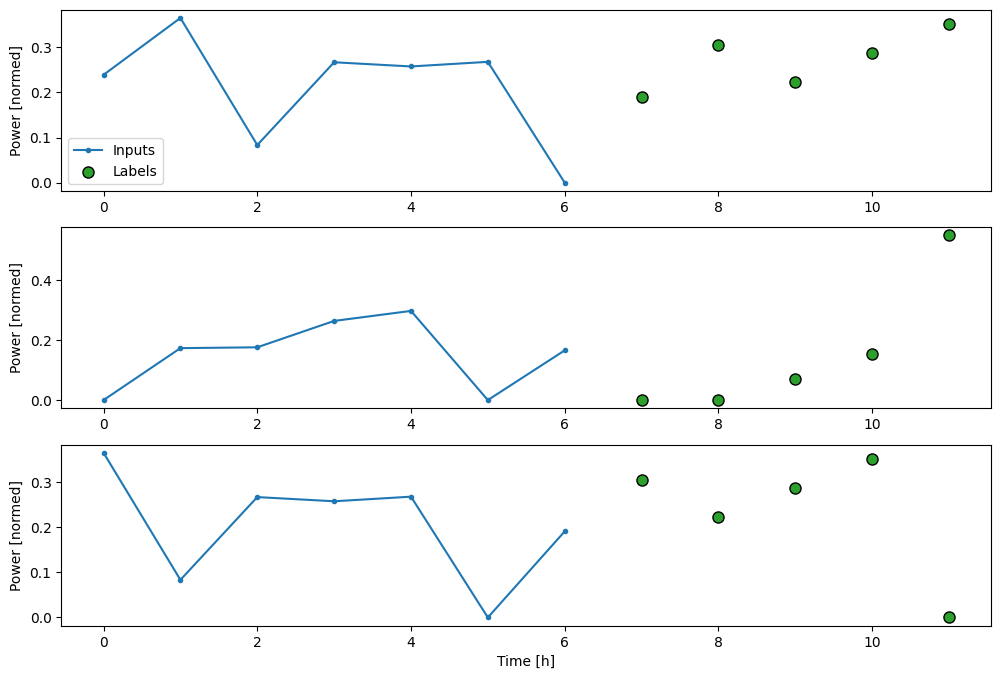

In [85]:
OUT_STEPS = 5
multi_window = WindowGenerator(input_width=7,
                               label_width=OUT_STEPS,
                               shift=OUT_STEPS)

multi_window.plot()
multi_window

In [ ]:
class MultiStepLastBaseline(tf.keras.Model):
  def call(self, inputs):
    return tf.tile(inputs[:, -1:, :], [1, OUT_STEPS, 1])

last_baseline = MultiStepLastBaseline()
last_baseline.compile(loss=tf.keras.losses.MeanSquaredError(),
                      metrics=[tf.keras.metrics.MeanAbsoluteError()])

multi_val_performance = {}
multi_performance = {}

multi_val_performance['Last'] = last_baseline.evaluate(multi_window.val, return_dict=True)
multi_performance['Last'] = last_baseline.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(last_baseline)

In [ ]:
class RepeatBaseline(tf.keras.Model):
  def call(self, inputs):
    return inputs

repeat_baseline = RepeatBaseline()
repeat_baseline.compile(loss=tf.keras.losses.MeanSquaredError(),
                        metrics=[tf.keras.metrics.MeanAbsoluteError()])

multi_val_performance['Repeat'] = repeat_baseline.evaluate(multi_window.val, return_dict=True)
multi_performance['Repeat'] = repeat_baseline.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(repeat_baseline)

In [86]:
MAX_EPOCHS = 20

def compile_and_fit(model, window, patience=2):
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')

  model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=[tf.keras.metrics.MeanAbsoluteError()])

  history = model.fit(window.train, epochs=MAX_EPOCHS,
                      validation_data=window.val,
                      callbacks=[early_stopping])
  return history

3/3 [==============================] - 0s 1ms/step - loss: 0.0479 - mean_absolute_error: 0.1618


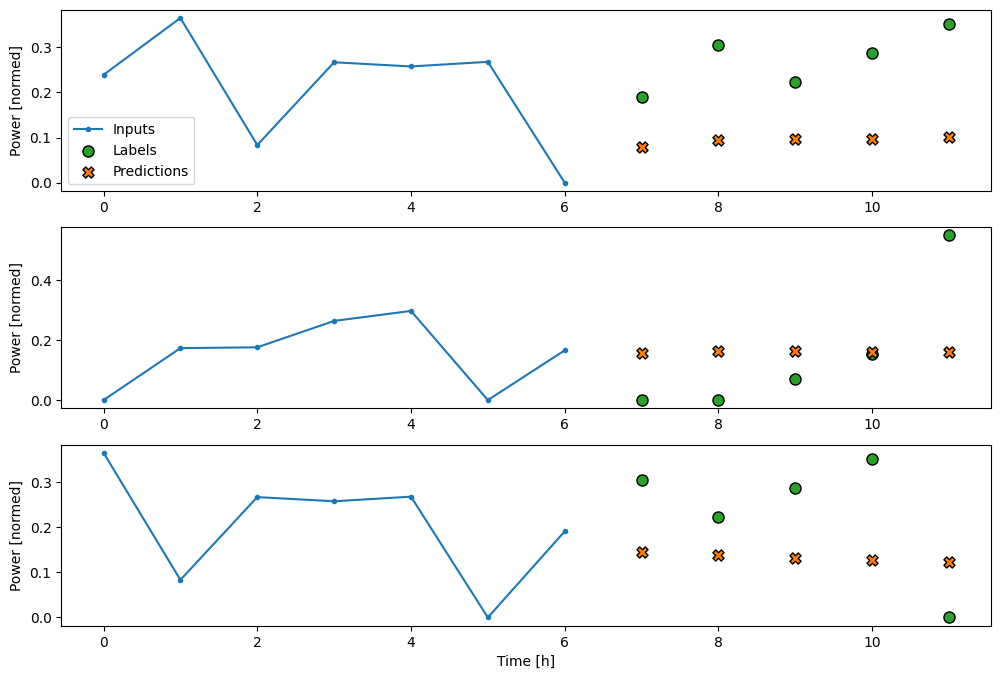

In [87]:
multi_linear_model = tf.keras.Sequential([
    # Take the last time-step.
    # Shape [batch, time, features] => [batch, 1, features]
    tf.keras.layers.Lambda(lambda x: x[:, -1:, :]),
    # Shape => [batch, 1, out_steps*features]
    tf.keras.layers.Dense(OUT_STEPS*num_features,
                          kernel_initializer=tf.initializers.zeros()),
    # Shape => [batch, out_steps, features]
    tf.keras.layers.Reshape([OUT_STEPS, num_features])
])

history = compile_and_fit(multi_linear_model, multi_window)

IPython.display.clear_output()
multi_val_performance['Linear'] = multi_linear_model.evaluate(multi_window.val, return_dict=True)
multi_performance['Linear'] = multi_linear_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(multi_linear_model)